# Stock Price Prediction Analysis - Simplified Version

This notebook demonstrates stock price prediction using LSTM and GRU neural networks in a simple, step-by-step way.

## What We'll Do:
1. Load and explore stock data
2. Prepare the data for training
3. Build LSTM and GRU models
4. Train the models
5. Compare results

## Step 1: Import Libraries

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# # Set plot style
# plt.style.use('seaborn-v0_8-darkgrid')
# sns.set_palette("husl")


## Step 2: Load the Data

We'll download the data directly from Yahoo Finance. This works both locally and in Google Colab.

In [48]:
# Import yfinance for downloading stock data
import yfinance as yf

# Download Adani Ports data from Yahoo Finance
ticker = "ADANIPORTS.NS"
start_date = "2021-03-28"
end_date = "2026-03-28"

print(f"Downloading {ticker} data from Yahoo Finance...")
df = yf.download(ticker, start=start_date, end=end_date)

# Flatten MultiIndex columns (newer yfinance versions)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ['_'.join(col).strip() for col in df.columns.values]
    
    # Rename columns for easier access
    df.rename(columns={
        'Close_ADANIPORTS.NS': 'Close',
        'Open_ADANIPORTS.NS': 'Open', 
        'High_ADANIPORTS.NS': 'High',
        'Low_ADANIPORTS.NS': 'Low',
        'Volume_ADANIPORTS.NS': 'Volume'
    }, inplace=True)

# Reset index to make Date a column
df.reset_index(inplace=True)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Display first few rows
print("\nFirst 5 rows of the data:")
df.head()


[*********************100%***********************]  1 of 1 completed


First 5 rows of the data:


,Close,High,Low,Open,Volume
Date,,,,,
2021-03-30,689.743225,696.975081,676.881220,682.462845,9109273
2021-03-31,681.831848,698.819401,678.143075,684.355689,7752226
2021-04-01,714.690613,720.272237,684.355697,692.606794,15017049
2021-04-05,720.515015,723.184488,694.062965,710.322482,15622924
2021-04-06,811.082886,827.730712,721.243005,733.862331,64555516


In [49]:
# Check data info
print("\nData Information:")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")



Data Information:
Shape: (1236, 5)

Data types:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [50]:
# Basic statistics
print("\nStatistical Summary:")
df.describe()



Statistical Summary:


,Close,High,Low,Open,Volume
count,1236.000000,1236.000000,1236.000000,1236.000000,1.236000e+03
mean,1017.986080,1033.057941,1004.147551,1019.900044,6.444519e+06
std,316.754664,318.869138,314.626066,317.169819,9.400372e+06
min,455.184814,499.034926,388.892904,451.789016,0.000000e+00
25%,727.237991,736.853042,718.605363,728.197738,2.258730e+06
50%,858.989716,874.246229,845.399059,859.038928,3.710298e+06
75%,1354.515869,1372.454579,1334.044864,1354.151770,6.655277e+06
max,1582.451172,1606.656534,1560.905968,1575.900024,1.155175e+08


## Step 3: Visualize the Stock Data

In [51]:
df.index


DatetimeIndex(['2021-03-30', '2021-03-31', '2021-04-01', '2021-04-05',
               '2021-04-06', '2021-04-07', '2021-04-08', '2021-04-09',
               '2021-04-12', '2021-04-13',
               ...
               '2026-03-13', '2026-03-16', '2026-03-17', '2026-03-18',
               '2026-03-19', '2026-03-20', '2026-03-23', '2026-03-24',
               '2026-03-25', '2026-03-27'],
              dtype='datetime64[ns]', name='Date', length=1236, freq=None)

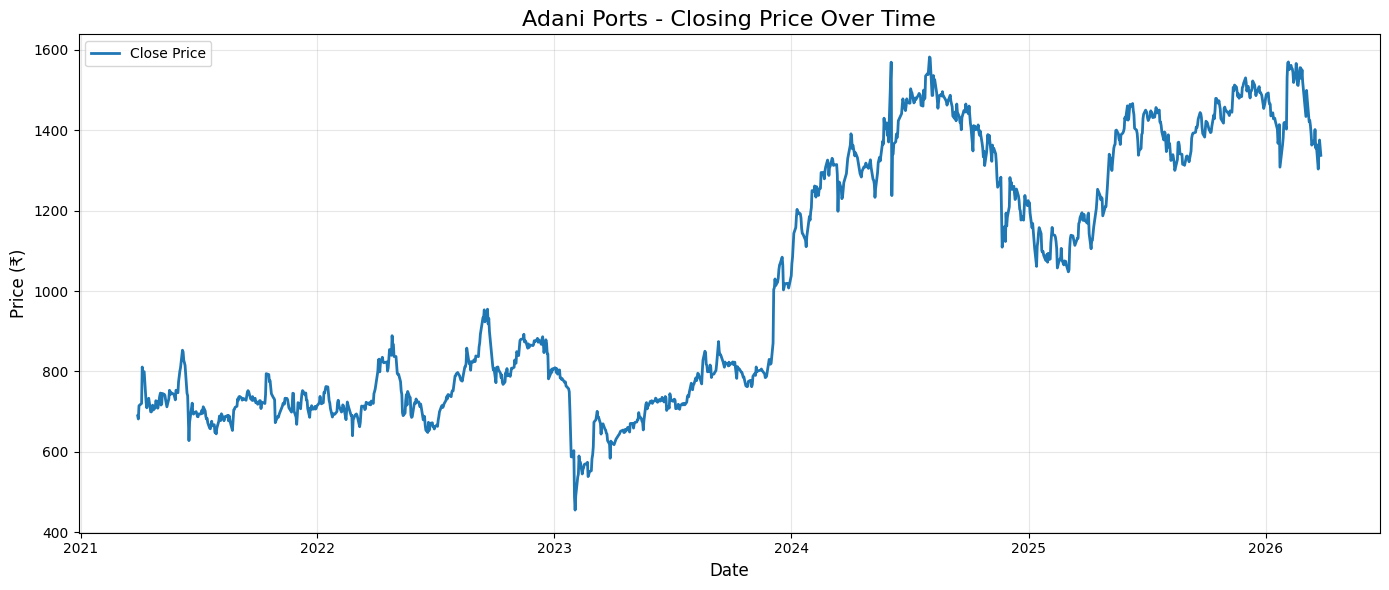

In [52]:
# Plot closing prices over time
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price', linewidth=2)
plt.title('Adani Ports - Closing Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


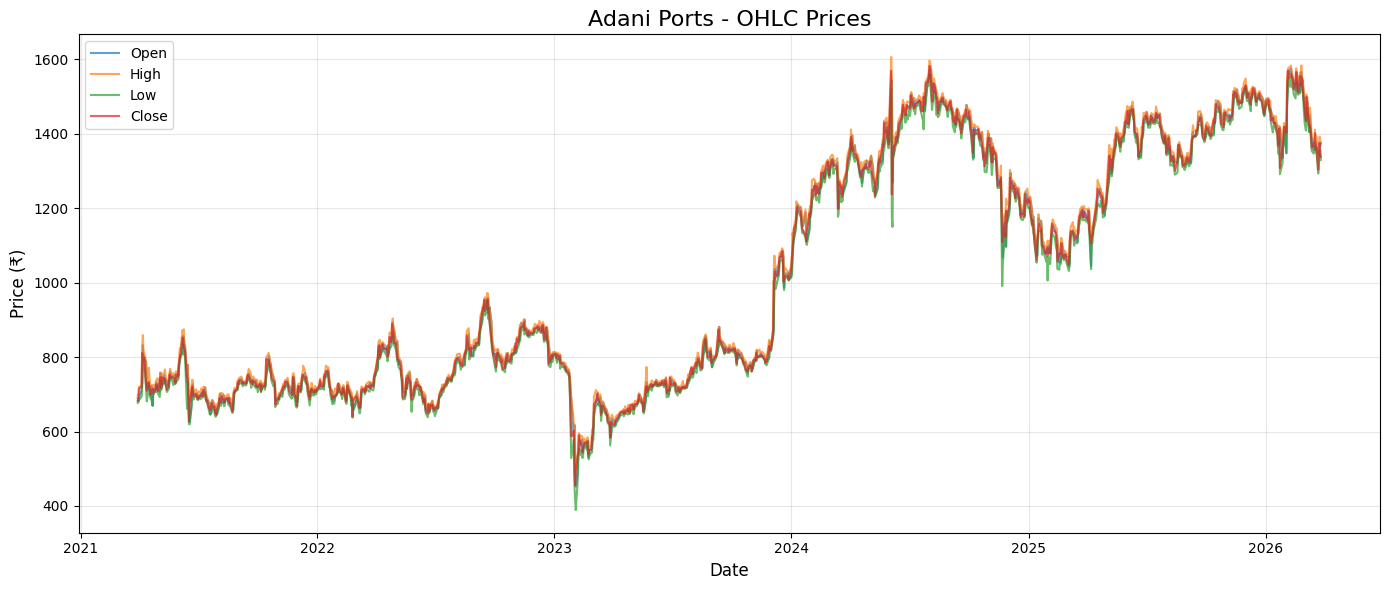

In [53]:
# Plot all OHLC data
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Open'], label='Open', alpha=0.7)
plt.plot(df.index, df['High'], label='High', alpha=0.7)
plt.plot(df.index, df['Low'], label='Low', alpha=0.7)
plt.plot(df.index, df['Close'], label='Close', alpha=0.7)
plt.title('Adani Ports - OHLC Prices', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Step 4: Prepare the Data for Training

We need to:
1. Handle missing values
2. Normalize the data (scale between 0 and 1)
3. Create sequences for time series prediction

In [54]:
# Handle missing values - forward fill then backward fill
df_clean = df.fillna(method='ffill').fillna(method='bfill')

# Check if any missing values remain
print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")


Missing values after cleaning: 0


In [68]:
# Select features to use for prediction
feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
data = df_clean[feature_columns].values

print(f"Data shape: {data.shape}")
print(f"Close price range: ${data[:, 3].min():.2f} - ${data[:, 3].max():.2f}")


Data shape: (1236, 5)
Close price range: $455.18 - $1582.45


In [61]:
df[['Open', 'High', 'Low', 'Close', 'Volume']].to_numpy()


array([[6.82462845e+02, 6.96975081e+02, 6.76881220e+02, 6.89743225e+02,
        9.10927300e+06],
       [6.84355689e+02, 6.98819401e+02, 6.78143075e+02, 6.81831848e+02,
        7.75222600e+06],
       [6.92606794e+02, 7.20272237e+02, 6.84355697e+02, 7.14690613e+02,
        1.50170490e+07],
       ...,
       [1.34300000e+03, 1.36100000e+03, 1.31359998e+03, 1.34419995e+03,
        3.13221200e+06],
       [1.35969995e+03, 1.39269995e+03, 1.35480005e+03, 1.37590002e+03,
        1.85653100e+06],
       [1.37500000e+03, 1.37500000e+03, 1.33009998e+03, 1.33780005e+03,
        2.66731300e+06]])

In [63]:
feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

feature_data = df[feature_columns].to_numpy()
target_data = df[["Close"]].to_numpy()
target_idx = feature_columns.index("Close")

In [71]:
feature_columns.index("Close")

3

In [74]:
feature_data[0].reshape(1,-1)


array([[6.82462845e+02, 6.96975081e+02, 6.76881220e+02, 6.89743225e+02,
        9.10927300e+06]])

In [91]:
import numpy as np

# 1. Create a dummy 2D dataset (2 samples, 3 features each)
feature_data = np.array([
    [10, 20, 30], 
    [40, 50, 60]
])

# feature_data.reshape(2,3)
a=feature_data.ravel()
a.shape
feature_data.shape


(2, 3)

In [30]:
# Create sequences for time series prediction
# We'll use 60 days of data to predict the next day's price
SEQUENCE_LENGTH = 60

# Create X (sequences) and y (next day's close price)
X = []
y = []

# Close price is at index 3 in our feature_columns
CLOSE_INDEX = 3

for i in range(len(data)-SEQUENCE_LENGTH):
    # Get the sequence of past days
    X.append(data[i:i+SEQUENCE_LENGTH])
    # Get the next day's close price
    y.append(data[i + SEQUENCE_LENGTH][CLOSE_INDEX])

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print(f"X shape: {X.shape}")  # (samples, timesteps, features)
print(f"y shape: {y.shape}")  # (samples,)


X shape: (1176, 60, 5)
y shape: (1176,)


In [33]:
X[0].shape


(60, 5)

In [35]:
# Split data into training and testing sets FIRST (80% train, 20% test)
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train_raw = X[:split_index]
X_test_raw = X[split_index:]
y_train_raw = y[:split_index]
y_test_raw = y[split_index:]

print(f"Training set size: {len(X_train_raw)}")
print(f"Testing set size: {len(X_test_raw)}")
print(f"Train/Test split ratio: {len(X_train_raw)/len(X_test_raw):.2f}")

# NOW normalize - fit scaler ONLY on training data
scaler = MinMaxScaler(feature_range=(0, 1))

# Reshape for scaling: (samples, timesteps, features) -> (samples*timesteps, features)
n_train_samples, n_timesteps, n_features = X_train_raw.shape
n_test_samples = X_test_raw.shape[0]

# Fit scaler on training data only
X_train_reshaped = X_train_raw.reshape(-1, n_features)
scaler.fit(X_train_reshaped)

# Transform both train and test using the SAME scaler (fit on train only!)
X_train = scaler.transform(X_train_reshaped).reshape(n_train_samples, n_timesteps, n_features)
X_test = scaler.transform(X_test_raw.reshape(-1, n_features)).reshape(n_test_samples, n_timesteps, n_features)

# Scale y values with a dedicated scaler (fit on train only)
y_scaler = MinMaxScaler(feature_range=(0, 1))
y_train = y_scaler.fit_transform(y_train_raw.reshape(-1, 1)).flatten()
y_test = y_scaler.transform(y_test_raw.reshape(-1, 1)).flatten()

print(f"\nNormalization applied AFTER split:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Training set size: 940
Testing set size: 236
Train/Test split ratio: 3.98

Normalization applied AFTER split:
X_train shape: (940, 60, 5)
X_test shape: (236, 60, 5)
y_train shape: (940,)
y_test shape: (236,)


In [92]:
X_train.shape

(940, 60, 5)

## Step 5: Build the LSTM Model

LSTM (Long Short-Term Memory) is a type of recurrent neural network good at learning long-term dependencies.

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

# Create LSTM model architecture
lstm_model = Sequential()

# First LSTM layer with dropout
lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(Dropout(0.2))

# Second LSTM layer with dropout
lstm_model.add(LSTM(units=50))
lstm_model.add(Dropout(0.2))

# Dense layer
lstm_model.add(Dense(units=50, activation='relu'))

# Output layer
lstm_model.add(Dense(units=1))

# Compile the model
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Display model summary
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,001 (132.82 KB)

 Trainable params: 34,001 (132.82 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the LSTM Model

In [37]:
# Set training parameters
EPOCHS = 50
BATCH_SIZE = 32
PATIENCE = 10  # Early stopping patience

# Create callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)

checkpoint = ModelCheckpoint(
    filepath='../models/lstm_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Train the model
print("Training LSTM model...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\nLSTM training completed!")


Training LSTM model...
Epoch 1/50
26/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0966
Epoch 1: val_loss improved from None to 0.00162, saving model to ../models/lstm_model.h5



Epoch 1: finished saving model to ../models/lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0427 - val_loss: 0.0016
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0071
Epoch 2: val_loss did not improve from 0.00162
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0057 - val_loss: 0.0018
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0038
Epoch 3: val_loss did not improve from 0.00162
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0039 - val_loss: 0.0076
Epoch 4/50
25/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0047
Epoch 4: val_loss did not improve from 0.00162
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0044 - val_loss: 0.0048
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0042
Epoch 5: val_loss did not improve from 0.00162
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0041 - val_loss: 0.0018
Epoch 6/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0032
Epoch 6: val_loss did not improve from 0.00162
30/30 ━━━

## Step 7: Build the GRU Model

GRU (Gated Recurrent Unit) is similar to LSTM but with a simpler architecture.

In [38]:
from tensorflow.keras.layers import GRU

# Create GRU model architecture
gru_model = Sequential()

# First GRU layer with dropout
gru_model.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
gru_model.add(Dropout(0.2))

# Second GRU layer with dropout
gru_model.add(GRU(units=50))
gru_model.add(Dropout(0.2))

# Dense layer
gru_model.add(Dense(units=50, activation='relu'))

# Output layer
gru_model.add(Dense(units=1))

# Compile the model
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Display model summary
gru_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 50)         │         8,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,451 (103.32 KB)

 Trainable params: 26,451 (103.32 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Train the GRU Model

In [39]:
# Train the GRU model
print("Training GRU model...")

gru_checkpoint = ModelCheckpoint(
    filepath='../models/gru_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, gru_checkpoint],
    verbose=1
)

print("\nGRU training completed!")


Training GRU model...
Epoch 1/50
28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0937
Epoch 1: val_loss improved from None to 0.00386, saving model to ../models/gru_model.h5



Epoch 1: finished saving model to ../models/gru_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0413 - val_loss: 0.0039
Epoch 2/50
28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0067
Epoch 2: val_loss improved from 0.00386 to 0.00109, saving model to ../models/gru_model.h5



Epoch 2: finished saving model to ../models/gru_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0056 - val_loss: 0.0011
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0034
Epoch 3: val_loss did not improve from 0.00109
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0033 - val_loss: 0.0047
Epoch 4/50
28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0036
Epoch 4: val_loss did not improve from 0.00109
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0035 - val_loss: 0.0093
Epoch 5/50
25/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0035
Epoch 5: val_loss did not improve from 0.00109
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0029 - val_loss: 0.0047
Epoch 6/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0023
Epoch 6: val_loss did not improve from 0.00109
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0026 - val_loss: 0.0090
Epoch 7/50
25/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0026
Epoch 7: val_loss did not improve from 0.00109
30/30 ━━━

## Step 9: Make Predictions

In [40]:
# Make predictions with both models
lstm_predictions = lstm_model.predict(X_test)
gru_predictions = gru_model.predict(X_test)

# Create a dataframe for comparison
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'LSTM_Prediction': lstm_predictions.flatten(),
    'GRU_Prediction': gru_predictions.flatten()
})

print("Predictions sample:")
predictions_df.head(10)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predictions sample:


,Actual,LSTM_Prediction,GRU_Prediction
0,0.691161,0.684449,0.637749
1,0.714676,0.688416,0.653991
2,0.705980,0.693504,0.667465
3,0.697550,0.699039,0.677858
4,0.695687,0.704378,0.684131
5,0.694178,0.709558,0.688237
6,0.651408,0.713514,0.687615
7,0.672616,0.716127,0.682629
8,0.675366,0.718236,0.679254
9,0.710771,0.719938,0.677524


## Step 10: Evaluate the Models

In [41]:
# Calculate evaluation metrics for LSTM
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_predictions))
lstm_mae = mean_absolute_error(y_test, lstm_predictions)
lstm_r2 = r2_score(y_test, lstm_predictions)

# Calculate evaluation metrics for GRU
gru_rmse = np.sqrt(mean_squared_error(y_test, gru_predictions))
gru_mae = mean_absolute_error(y_test, gru_predictions)
gru_r2 = r2_score(y_test, gru_predictions)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['LSTM', 'GRU'],
    'RMSE': [lstm_rmse, gru_rmse],
    'MAE': [lstm_mae, gru_mae],
    'R² Score': [lstm_r2, gru_r2]
})

print("\nModel Comparison:")
print(comparison_df.to_string(index=False))

# Determine the best model
best_model = 'LSTM' if lstm_r2 > gru_r2 else 'GRU'
print(f"\n✓ Best performing model based on R² Score: {best_model}")



Model Comparison:
Model     RMSE      MAE  R² Score
 LSTM 0.040295 0.031663  0.636743
  GRU 0.033022 0.025594  0.756033

✓ Best performing model based on R² Score: GRU


## Step 11: Visualize Training History

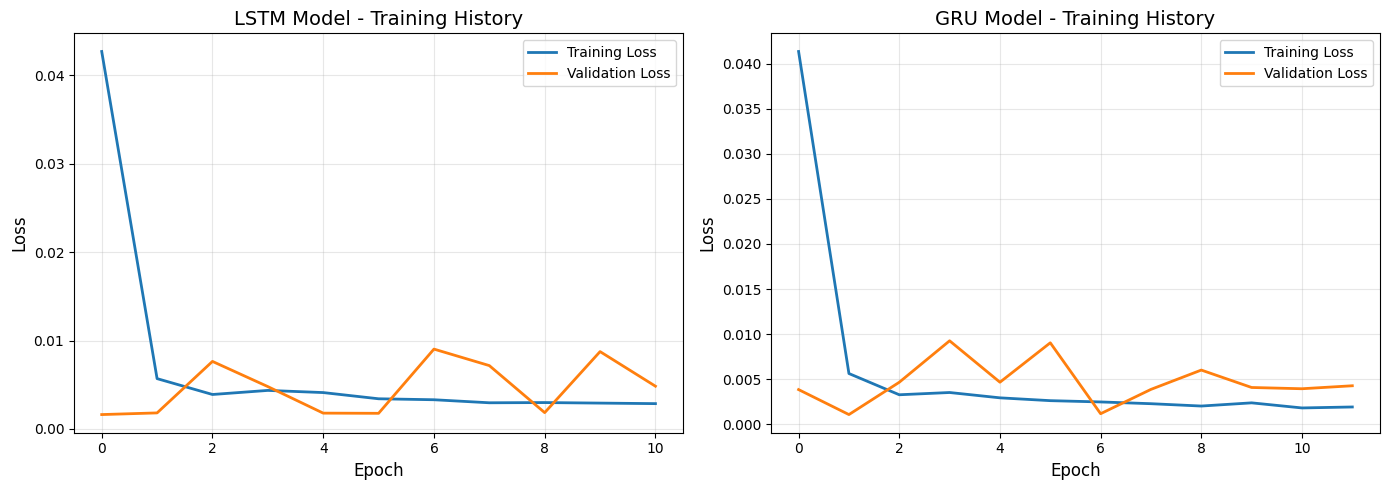

In [42]:
# Plot training history for LSTM
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(lstm_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('LSTM Model - Training History', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot training history for GRU
plt.subplot(1, 2, 2)
plt.plot(gru_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(gru_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('GRU Model - Training History', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 12: Visualize Predictions vs Actual Values

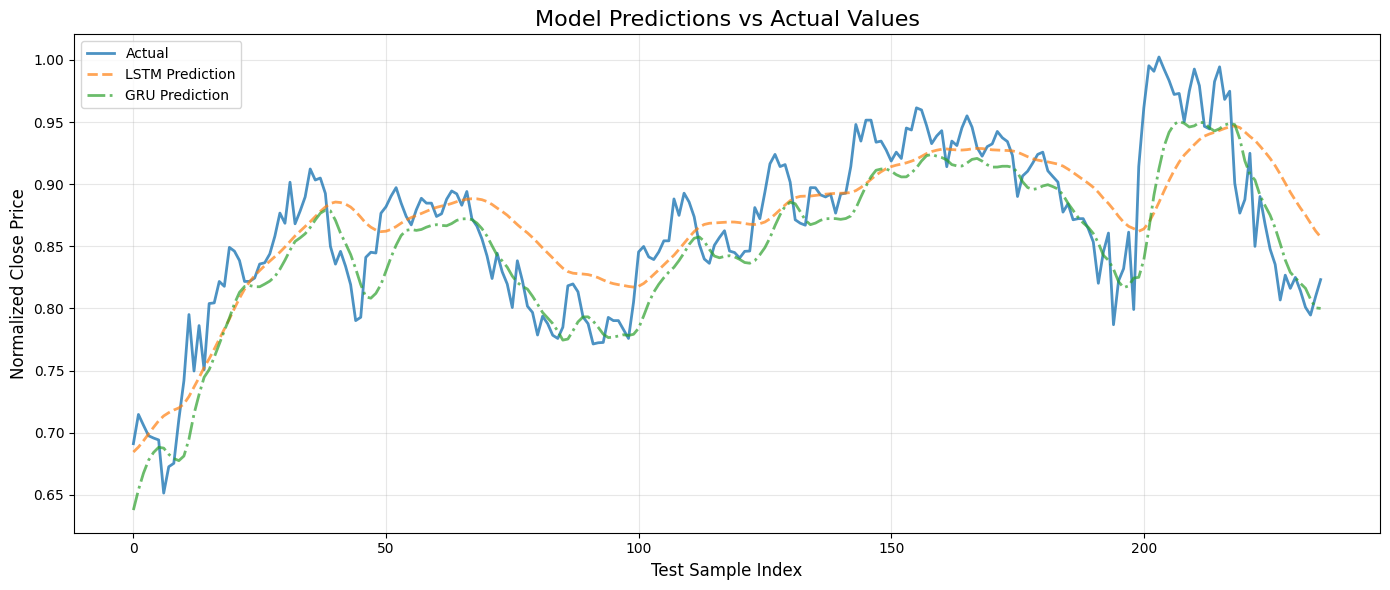

In [43]:
# Plot predictions vs actual
plt.figure(figsize=(14, 6))

plt.plot(predictions_df.index, predictions_df['Actual'], label='Actual', linewidth=2, alpha=0.8)
plt.plot(predictions_df.index, predictions_df['LSTM_Prediction'], label='LSTM Prediction', linewidth=2, alpha=0.7, linestyle='--')
plt.plot(predictions_df.index, predictions_df['GRU_Prediction'], label='GRU Prediction', linewidth=2, alpha=0.7, linestyle='-.')

plt.title('Model Predictions vs Actual Values', fontsize=16)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Normalized Close Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


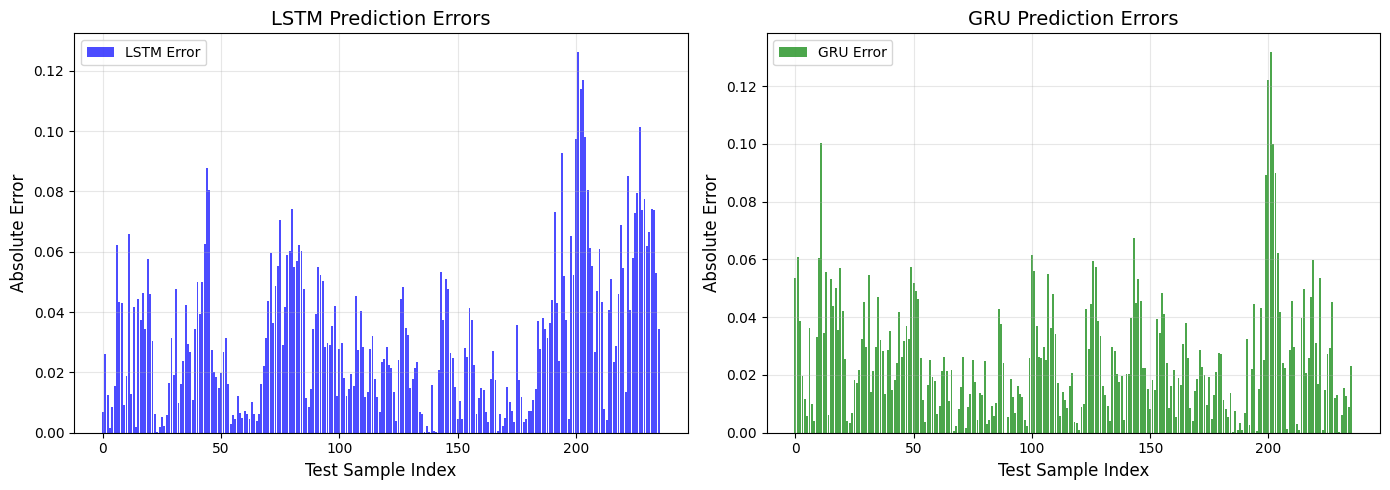

In [44]:
# Plot prediction errors
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
lstm_errors = np.abs(predictions_df['Actual'] - predictions_df['LSTM_Prediction'])
plt.bar(range(len(lstm_errors)), lstm_errors, alpha=0.7, color='blue', label='LSTM Error')
plt.title('LSTM Prediction Errors', fontsize=14)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Absolute Error', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
gru_errors = np.abs(predictions_df['Actual'] - predictions_df['GRU_Prediction'])
plt.bar(range(len(gru_errors)), gru_errors, alpha=0.7, color='green', label='GRU Error')
plt.title('GRU Prediction Errors', fontsize=14)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Absolute Error', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 13: Scatter Plot - Predicted vs Actual

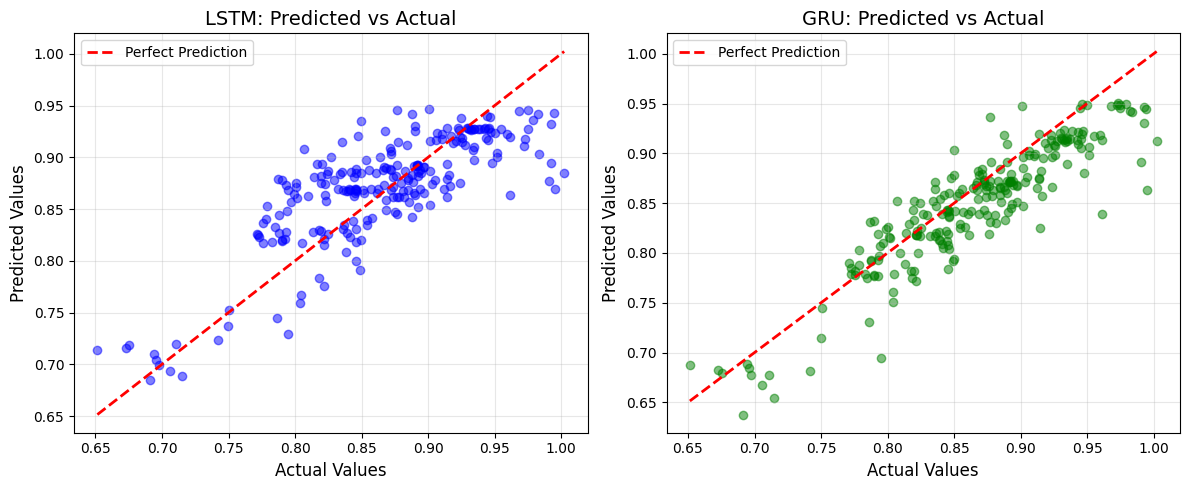

In [45]:
# Scatter plot for LSTM
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(predictions_df['Actual'], predictions_df['LSTM_Prediction'], alpha=0.5, color='blue')
plt.plot([predictions_df['Actual'].min(), predictions_df['Actual'].max()], 
         [predictions_df['Actual'].min(), predictions_df['Actual'].max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.title('LSTM: Predicted vs Actual', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Scatter plot for GRU
plt.subplot(1, 2, 2)
plt.scatter(predictions_df['Actual'], predictions_df['GRU_Prediction'], alpha=0.5, color='green')
plt.plot([predictions_df['Actual'].min(), predictions_df['Actual'].max()], 
         [predictions_df['Actual'].min(), predictions_df['Actual'].max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.title('GRU: Predicted vs Actual', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

In this notebook, we:

1. ✅ **Loaded** Adani Ports stock data
2. ✅ **Explored** the data with visualizations
3. ✅ **Preprocessed** the data (cleaning, normalization, sequence creation)
4. ✅ **Built** LSTM and GRU neural network models
5. ✅ **Trained** both models with early stopping
6. ✅ **Evaluated** performance using RMSE, MAE, and R² Score
7. ✅ **Compared** the models visually

### Key Takeaways:
- Both LSTM and GRU models can learn patterns in time series data
- GRU is computationally more efficient but LSTM may capture longer dependencies
- The model with higher R² Score and lower RMSE/MAE performs better
- Early stopping prevents overfitting by monitoring validation loss